# Task 06 — Classification Algorithms Comparison
Comparing six classification algorithms for predicting customer churn on the
Telco Customer Churn dataset (feature-engineered version from Task 03).

**Goal:** train Logistic Regression, Decision Tree, Random Forest, Gradient
Boosting, K-Nearest Neighbors, and SVM on the same train/test split and the
same preprocessing pipeline, then compare them on Accuracy, Precision,
Recall, F1, ROC-AUC, and training time to recommend the best model for
production churn prediction.

In [1]:
import sys
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw_data, get_train_test_split, RANDOM_SEED
from src.preprocessing import build_pipeline, get_feature_types
from src.modeling import get_candidate_models, run_comparison, cross_validate_model

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_SEED

42

## 1. Load Data
Reusing the feature-engineered Telco churn dataset produced in Task 03 (33 columns, incl. engineered features like `tenure_group`, `num_services`, `avg_monthly_spend`, `customer_segment`).

In [2]:
df = load_raw_data()
print(df.shape)
df.head()

(7043, 33)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary,tenure_group,num_services,avg_monthly_spend,has_internet,TotalCharges_log,tenure_x_monthly,charges_per_service,spend_to_tenure_ratio,tenure^2,tenure MonthlyCharges,MonthlyCharges^2,customer_segment
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12,2,29.850000,1,3.429137,29.85,14.9250,14.925000,1.0,29.85,891.0225,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48,4,55.573529,1,7.544597,1936.30,14.2375,53.985714,1156.0,1936.30,3243.3025,3
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12,4,54.075000,1,4.692723,107.70,13.4625,36.050000,4.0,107.70,2899.8225,0
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48,4,40.905556,1,7.518471,1903.50,10.5750,40.016304,2025.0,1903.50,1789.2900,3
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12,2,75.825000,1,5.028148,141.40,35.3500,50.550000,4.0,141.40,4998.4900,2


In [3]:
df['Churn'].value_counts(normalize=True).round(3)

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

The dataset is moderately imbalanced (~26.5% churn). We use stratified train/test splitting and ROC-AUC as the primary comparison metric since it is threshold-independent and robust to imbalance.

## 2. Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = get_train_test_split(df)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train churn rate:', y_train.mean().round(3), ' Test churn rate:', y_test.mean().round(3))

numeric_cols, categorical_cols = get_feature_types(X_train)
print(f'{len(numeric_cols)} numeric columns, {len(categorical_cols)} categorical columns')

Train: (5634, 31)  Test: (1409, 31)
Train churn rate: 0.265  Test churn rate: 0.265
14 numeric columns, 17 categorical columns


## 3. Preprocessing Pipeline
All models share the same `ColumnTransformer`: `StandardScaler` for numeric
features and `OneHotEncoder` for categorical features, wrapped with each
estimator in a single `sklearn.Pipeline` (see `src/preprocessing.py`). This
guarantees a fair, apples-to-apples comparison and prevents data leakage,
since scaling/encoding is fit only on the training fold.

## 4. Candidate Models
Six classifiers spanning linear, tree-based, distance-based, and margin-based families:

In [5]:
for name, est in get_candidate_models().items():
    print(f'- {name}: {est.__class__.__name__}')

- Logistic Regression: LogisticRegression
- Decision Tree: DecisionTreeClassifier
- Random Forest: RandomForestClassifier
- Gradient Boosting: GradientBoostingClassifier
- K-Nearest Neighbors: KNeighborsClassifier
- SVM (RBF): SVC


## 5. Train & Evaluate All Models

In [6]:
results_df, fitted_pipelines = run_comparison(X_train, y_train, X_test, y_test)
results_df.drop(columns=['y_pred', 'y_proba']).round(3)

,model,accuracy,precision,recall,f1,roc_auc,train_time_sec
0,Logistic Regression,0.805,0.664,0.535,0.593,0.847,0.125
1,Gradient Boosting,0.809,0.687,0.516,0.589,0.846,2.464
2,Random Forest,0.779,0.605,0.484,0.538,0.822,3.089
3,K-Nearest Neighbors,0.779,0.592,0.543,0.566,0.820,0.038
4,SVM (RBF),0.798,0.662,0.487,0.561,0.800,8.198
5,Decision Tree,0.720,0.472,0.479,0.475,0.645,0.116


## 6. Class Distribution (Figure 1)

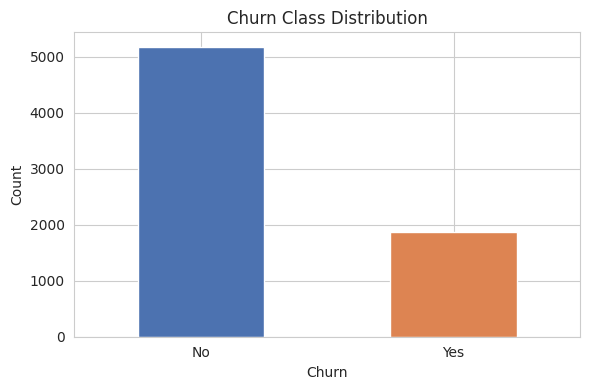

In [7]:
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Churn Class Distribution')
plt.xlabel('Churn'); plt.ylabel('Count'); plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/01_class_distribution.png', dpi=150)
plt.show()

## 7. Metric Comparison Across Models (Figure 2)

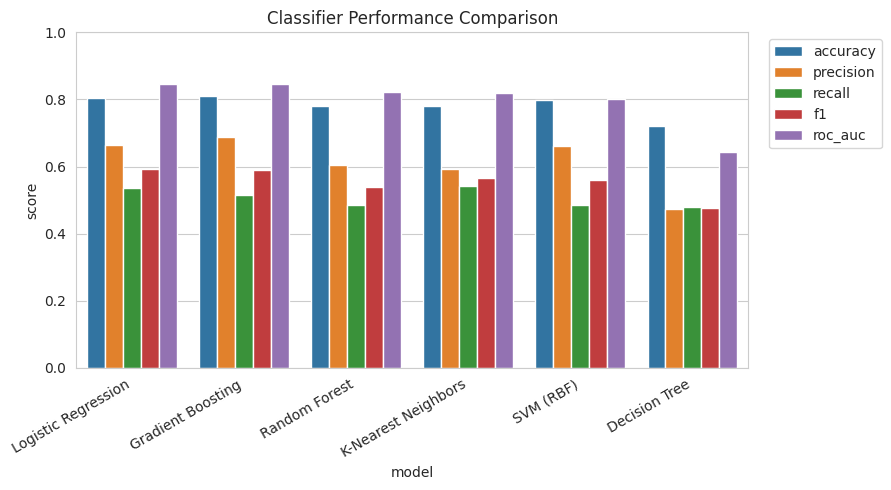

In [8]:
metrics_long = results_df.melt(
    id_vars='model', value_vars=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    var_name='metric', value_name='score'
)
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_long, x='model', y='score', hue='metric')
plt.xticks(rotation=30, ha='right')
plt.title('Classifier Performance Comparison')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('figures/02_metric_comparison.png', dpi=150)
plt.show()

## 8. ROC Curves (Figure 3)

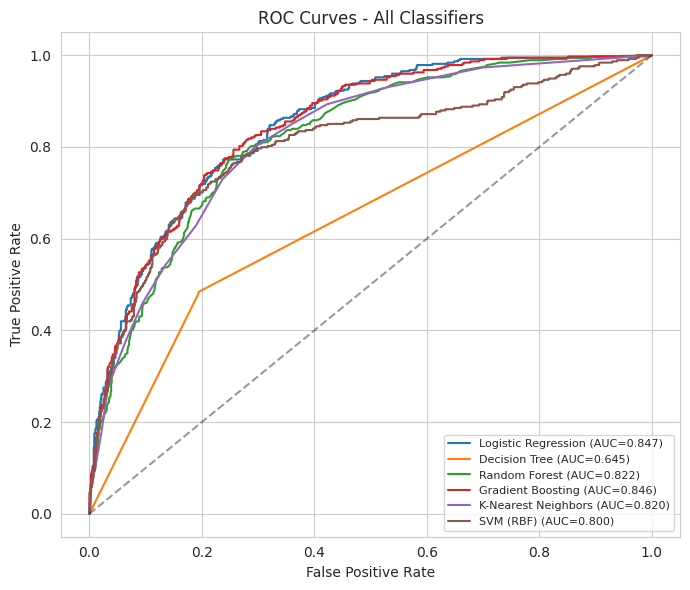

In [9]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = results_df.loc[results_df.model == name, 'roc_auc'].values[0]
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Classifiers')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('figures/03_roc_curves.png', dpi=150)
plt.show()

## 9. Confusion Matrix — Best Model (Figure 4)

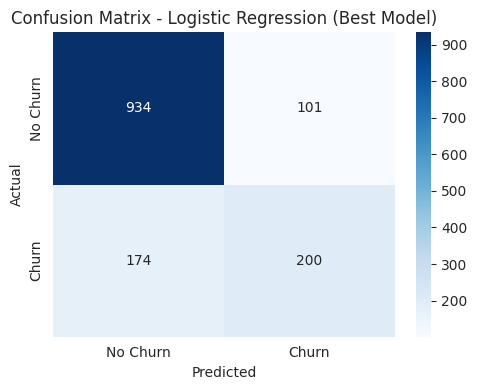

Best model: Logistic Regression

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [10]:
from sklearn.metrics import confusion_matrix, classification_report

best_name = results_df.iloc[0]['model']
best_pipe = fitted_pipelines[best_name]
y_pred_best = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_name} (Best Model)')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('figures/04_confusion_matrix_best_model.png', dpi=150)
plt.show()

print(f'Best model: {best_name}\n')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

## 10. Training Time Comparison (Figure 5)

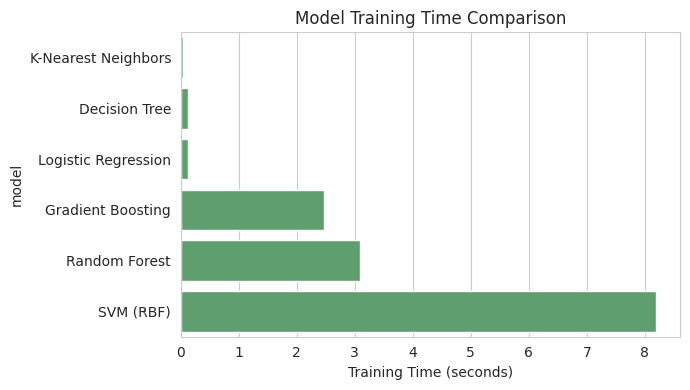

In [11]:
plt.figure(figsize=(7, 4))
sns.barplot(data=results_df.sort_values('train_time_sec'), x='train_time_sec', y='model', color='#55A868')
plt.xlabel('Training Time (seconds)')
plt.title('Model Training Time Comparison')
plt.tight_layout()
plt.savefig('figures/05_training_time_comparison.png', dpi=150)
plt.show()

## 11. Feature Importance — Random Forest (Figure 6)

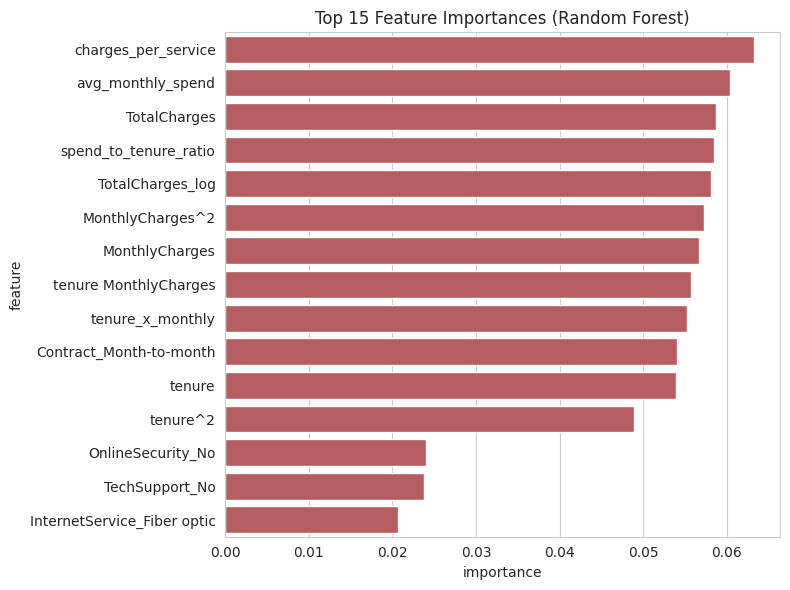

In [12]:
rf_pipe = fitted_pipelines['Random Forest']
ohe = rf_pipe.named_steps['preprocessor'].transformers_[1][1]
cat_cols = rf_pipe.named_steps['preprocessor'].transformers_[1][2]
num_cols = rf_pipe.named_steps['preprocessor'].transformers_[0][2]
all_cols = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))

importances = rf_pipe.named_steps['classifier'].feature_importances_
imp_df = pd.DataFrame({'feature': all_cols, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance', y='feature', color='#C44E52')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('figures/06_feature_importance_rf.png', dpi=150)
plt.show()

## 12. 5-Fold Cross-Validation (Robustness Check)
A single train/test split can be noisy. We cross-validate ROC-AUC across 5
stratified folds for every model to confirm the ranking is stable.

In [13]:
cv_results = [cross_validate_model(name, est, df.drop(columns=['Churn', 'Churn_binary']), df['Churn_binary'])
              for name, est in get_candidate_models().items()]
cv_df = pd.DataFrame(cv_results).sort_values('cv_roc_auc_mean', ascending=False).reset_index(drop=True)
cv_df.round(3)

,model,cv_roc_auc_mean,cv_roc_auc_std
0,Logistic Regression,0.849,0.010
1,Gradient Boosting,0.845,0.010
2,Random Forest,0.829,0.012
3,K-Nearest Neighbors,0.823,0.011
4,SVM (RBF),0.796,0.014
5,Decision Tree,0.653,0.020


## 13. Conclusion

**Logistic Regression** and **Gradient Boosting** are effectively tied for
best ROC-AUC (~0.845-0.847), both meaningfully ahead of Random Forest, KNN,
and SVM, with **Decision Tree** clearly the weakest (heavy overfitting,
ROC-AUC 0.645).

Given the near-tie in ROC-AUC, **Logistic Regression is the recommended
production model**: it trains ~15x faster than Gradient Boosting, is fully
interpretable (coefficients map directly to churn drivers for the business),
and its recall/precision trade-off is easy to tune via the decision
threshold. Gradient Boosting remains a strong candidate if a small non-linear
performance edge becomes worth the added training/inference cost and reduced
interpretability at scale.

See `reports/REPORT.md` for the full written report.